In [ ]:
# SECTION 1: IMPORT LIBRARIES

# Core deep learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

# Numerical & image processing
import numpy as np
import cv2
import os
import glob

# Visualization
import matplotlib.pyplot as plt

# Utilities
from sklearn.model_selection import train_test_split

# Reproducibility — ensures same results every time we run the notebook
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Check TensorFlow version and GPU availability
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# SECTION 3: LOAD DATASET

import pandas as pd

# Dataset path (as provided)
DATASET_PATH = '/content/drive/MyDrive/Autoencoder_project/fashion_MNIST/'

TRAIN_CSV = os.path.join(DATASET_PATH, 'fashion-mnist_train.csv')
TEST_CSV  = os.path.join(DATASET_PATH, 'fashion-mnist_test.csv')

# Load CSVs into pandas DataFrames
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())

Train shape: (60000, 785)
Test shape: (10000, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  

Train images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)
Pixel value range: 0 to 255


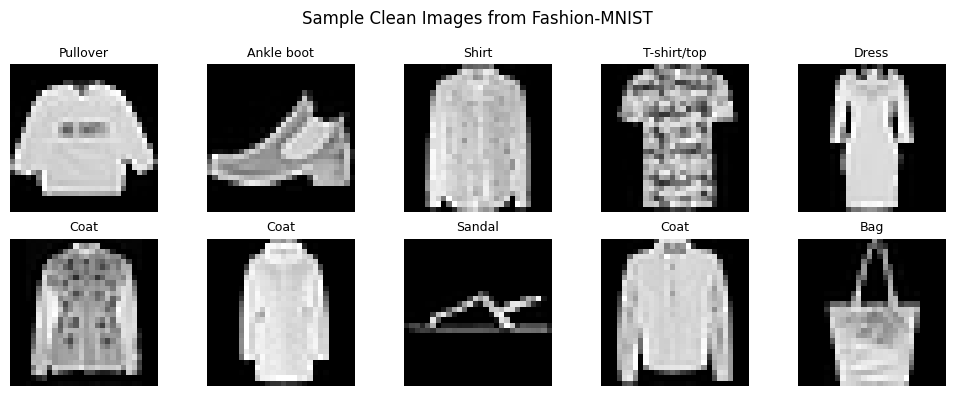

In [ ]:
# SECTION 4: EXPLORE THE DATASET

IMG_SIZE = 28  # Fashion-MNIST images are 28x28 pixels

# Separate labels and pixel values
train_labels = train_df['label'].values
train_pixels = train_df.drop('label', axis=1).values

test_labels = test_df['label'].values
test_pixels = test_df.drop('label', axis=1).values

# Reshape flattened pixels (784,) into image grids (28, 28)
train_images = train_pixels.reshape(-1, IMG_SIZE, IMG_SIZE)
test_images  = test_pixels.reshape(-1, IMG_SIZE, IMG_SIZE)

print("Train images shape:", train_images.shape)
print("Test images shape:", test_images.shape)
print("Pixel value range:", train_images.min(), "to", train_images.max())

# Class names (for reference only — we won't use labels for training)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Visualize a few sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(class_names[train_labels[i]], fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Clean Images from Fashion-MNIST")
plt.tight_layout()
plt.show()

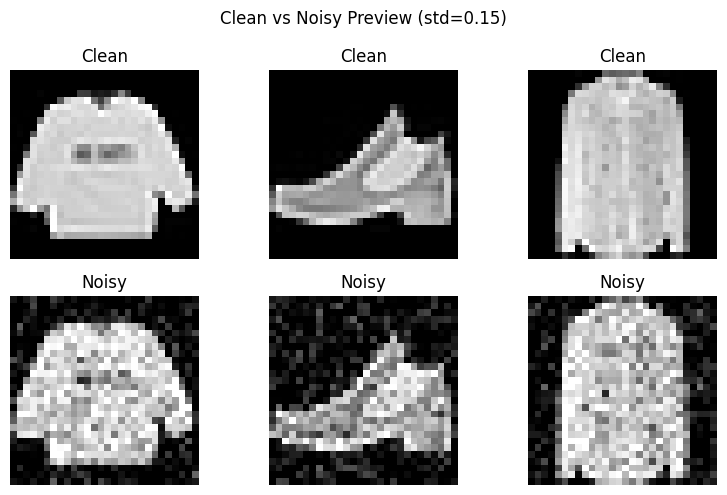

In [ ]:
# SECTION 5: GENERATE NOISY IMAGES

def add_gaussian_noise(images, mean=0.0, std=0.15):

    noise = np.random.normal(loc=mean, scale=std, size=images.shape)
    noisy_images = images + noise
    # Clip values so they stay within valid pixel range [0, 1]
    noisy_images = np.clip(noisy_images, 0.0, 1.0)
    return noisy_images

# NOTE: We normalize to [0,1] first (Section 6), then apply noise.
# For now, let's preview noise on a temporarily normalized copy of 3 images.

preview_clean = train_images[:3].astype('float32') / 255.0
preview_noisy = add_gaussian_noise(preview_clean, std=0.15)

# Visualize clean vs noisy side-by-side
plt.figure(figsize=(8, 5))
for i in range(3):
    plt.subplot(2, 3, i + 1)
    plt.imshow(preview_clean[i], cmap='gray')
    plt.title("Clean")
    plt.axis('off')

    plt.subplot(2, 3, i + 4)
    plt.imshow(preview_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
plt.suptitle("Clean vs Noisy Preview (std=0.15)")
plt.tight_layout()
plt.show()

In [ ]:
# -----DATA PREPROCESSING-----

# Step 1: Normalize pixel values to [0, 1]
train_images_norm = train_images.astype('float32') / 255.0
test_images_norm  = test_images.astype('float32') / 255.0

# Step 2: Add channel dimension -> (num_images, 28, 28, 1)
train_images_norm = np.expand_dims(train_images_norm, axis=-1)
test_images_norm  = np.expand_dims(test_images_norm, axis=-1)

print("Train images shape (with channel):", train_images_norm.shape)
print("Test images shape (with channel):", test_images_norm.shape)

# Step 3: Generate noisy versions of the FULL dataset
NOISE_STD = 0.15

train_images_noisy = add_gaussian_noise(train_images_norm, std=NOISE_STD)
test_images_noisy  = add_gaussian_noise(test_images_norm, std=NOISE_STD)

# Step 4: Split TRAINING data into Train + Validation sets
X_train_noisy, X_val_noisy, X_train_clean, X_val_clean = train_test_split(
    train_images_noisy,
    train_images_norm,
    test_size=0.1,      # 10% of training data becomes validation
    random_state=SEED
)

# Test set
X_test_noisy = test_images_noisy
X_test_clean = test_images_norm

print("\nFinal dataset shapes:")
print("Train (noisy):", X_train_noisy.shape, "| Train (clean):", X_train_clean.shape)
print("Val   (noisy):", X_val_noisy.shape,   "| Val   (clean):", X_val_clean.shape)
print("Test  (noisy):", X_test_noisy.shape,  "| Test  (clean):", X_test_clean.shape)

Train images shape (with channel): (60000, 28, 28, 1)
Test images shape (with channel): (10000, 28, 28, 1)

Final dataset shapes:
Train (noisy): (54000, 28, 28, 1) | Train (clean): (54000, 28, 28, 1)
Val   (noisy): (6000, 28, 28, 1) | Val   (clean): (6000, 28, 28, 1)
Test  (noisy): (10000, 28, 28, 1) | Test  (clean): (10000, 28, 28, 1)


In [ ]:
# SECTION 7: BUILD THE CONVOLUTIONAL AUTOENCODER

def build_autoencoder(input_shape=(28, 28, 1)):

    inputs = layers.Input(shape=input_shape, name="input_noisy_image")

    # Block 1: 28x28x1 -> 14x14x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="enc_conv1")(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same', name="enc_pool1")(x)

    # Block 2: 14x14x32 -> 7x7x64
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="enc_conv2")(x)
    x = layers.MaxPooling2D((2, 2), padding='same', name="enc_pool2")(x)

    # Smallest, most compressed representation: 7x7x128
    latent = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="bottleneck")(x)

    # Block 1: 7x7x128 -> 14x14x64
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same', name="dec_conv1")(latent)

    # Block 2: 14x14x64 -> 28x28x32
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same', name="dec_conv2")(x)

    # 28x28x32 -> 28x28x1, sigmoid squashes output to [0,1] pixel range
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="output_denoised_image")(x)

    # Build the model
    autoencoder = Model(inputs, outputs, name="Convolutional_Autoencoder")
    return autoencoder

# Instantiate the model
autoencoder = build_autoencoder(input_shape=(28, 28, 1))

# Display architecture summary
autoencoder.summary()

Model: "Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_noisy_image (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2DTranspose)     │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2DTranspose)     │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_denoised_image (Conv2D)  │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,217 (723.50 KB)

 Trainable params: 185,217 (723.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# -----TRAIN THE MODEL-----

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

autoencoder.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mse']
)

CHECKPOINT_PATH = os.path.join(DATASET_PATH, 'best_autoencoder.keras')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

EPOCHS = 50
BATCH_SIZE = 128

history = autoencoder.fit(
    X_train_noisy, X_train_clean,
    validation_data=(X_val_noisy, X_val_clean),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0414 - mse: 0.0414
Epoch 1: val_loss improved from None to 0.00962, saving model to /content/drive/MyDrive/Autoencoder_project/fashion_MNIST/best_autoencoder.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Autoencoder_project/fashion_MNIST/best_autoencoder.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - loss: 0.0199 - mse: 0.0199 - val_loss: 0.0096 - val_mse: 0.0096 - learning_rate: 0.0010
Epoch 2/50
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0089 - mse: 0.0089
Epoch 2: val_loss improved from 0.00962 to 0.00722, saving model to /content/drive/MyDrive/Autoencoder_project/fashion_MNIST/best_autoencoder.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Autoencoder_project/fashion_MNIST/best_autoencoder.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0083 - mse: 0.0083 - val_loss: 0.0072 - val_mse: 0.0072 - learning_rate: 0.0010
Epoch 3/50
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/s

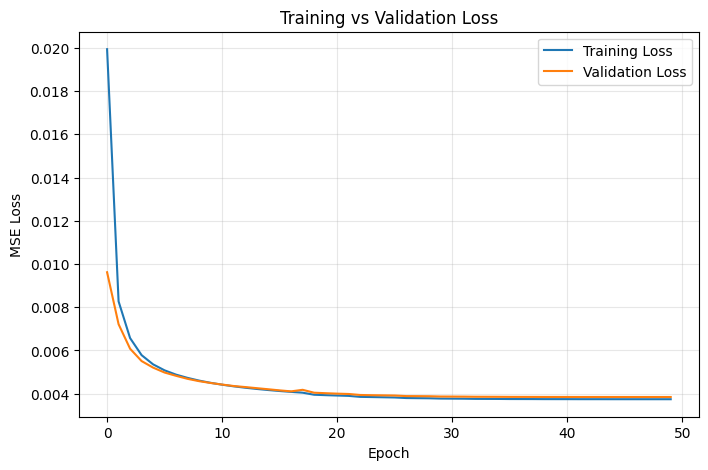

Test Loss (MSE): 0.00381
Test MSE Metric: 0.00381


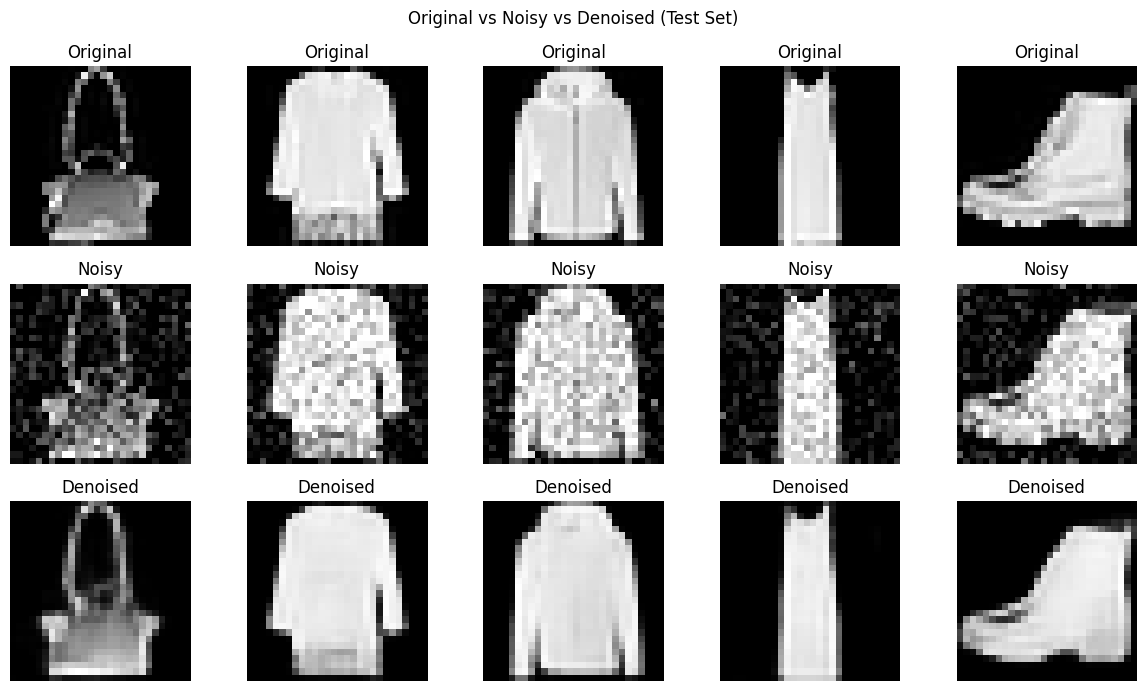

In [ ]:
# -----EVALUATE THE MODEL-----

# Plot Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Evaluate on Test Set
test_loss, test_mse = autoencoder.evaluate(X_test_noisy, X_test_clean, verbose=0)
print(f"Test Loss (MSE): {test_loss:.5f}")
print(f"Test MSE Metric: {test_mse:.5f}")

# Generate reconstructions on test set
reconstructed_images = autoencoder.predict(X_test_noisy, verbose=0)

# Visualize: Original vs Noisy vs Reconstructed
NUM_SAMPLES = 5
indices = np.random.choice(len(X_test_noisy), NUM_SAMPLES, replace=False)

plt.figure(figsize=(12, 7))
for i, idx in enumerate(indices):
    # Original (clean)
    plt.subplot(3, NUM_SAMPLES, i + 1)
    plt.imshow(X_test_clean[idx].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    plt.subplot(3, NUM_SAMPLES, i + 1 + NUM_SAMPLES)
    plt.imshow(X_test_noisy[idx].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Reconstructed
    plt.subplot(3, NUM_SAMPLES, i + 1 + 2 * NUM_SAMPLES)
    plt.imshow(reconstructed_images[idx].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.suptitle("Original vs Noisy vs Denoised (Test Set)")
plt.tight_layout()
plt.show()

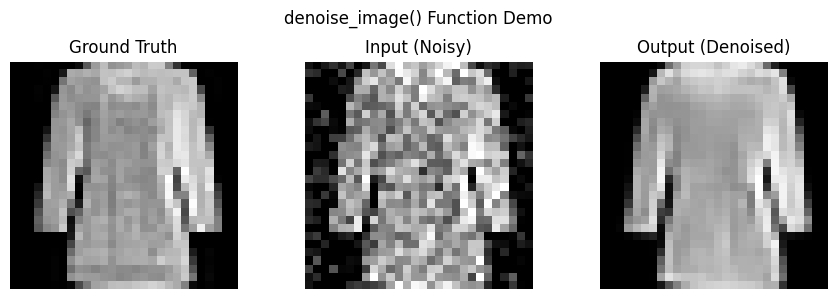

In [ ]:
# SECTION 10: DENOISE NEW IMAGES

def denoise_image(model, noisy_image):

    # Ensure correct shape: (28, 28, 1)
    if noisy_image.ndim == 2:
        noisy_image = np.expand_dims(noisy_image, axis=-1)

    # Add batch dimension: (1, 28, 28, 1)
    input_batch = np.expand_dims(noisy_image, axis=0)

    # Run inference (no training happens here)
    denoised_batch = model.predict(input_batch, verbose=0)

    # Remove batch and channel dimensions -> back to (28, 28)
    denoised_image = denoised_batch[0].squeeze()

    return denoised_image


# Demo
sample_idx = np.random.randint(0, len(X_test_noisy))
sample_noisy = X_test_noisy[sample_idx]
sample_clean = X_test_clean[sample_idx]

denoised_result = denoise_image(autoencoder, sample_noisy)

plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.imshow(sample_clean.squeeze(), cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sample_noisy.squeeze(), cmap='gray')
plt.title("Input (Noisy)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(denoised_result, cmap='gray')
plt.title("Output (Denoised)")
plt.axis('off')

plt.suptitle("denoise_image() Function Demo")
plt.tight_layout()
plt.show()

In [ ]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import numpy as np

# ROBUSTNESS CHECK: Test at a different noise level than training
X_test_noisy_high = add_gaussian_noise(X_test_clean, mean=0.0, std=0.25)

high_noise_loss, high_noise_mse = autoencoder.evaluate(X_test_noisy_high, X_test_clean, verbose=0)
print(f"Test Loss at std=0.25 (unseen noise level): {high_noise_loss:.5f}")
print(f"Test MSE at std=0.25 (unseen noise level): {high_noise_mse:.5f}")

denoised_high_noise = autoencoder.predict(X_test_noisy_high, verbose=0)

psnr_scores_high = []
ssim_scores_high = []

for i in range(len(X_test_clean)):
    clean_img = X_test_clean[i].squeeze()
    denoised_img = denoised_high_noise[i].squeeze()
    psnr_scores_high.append(peak_signal_noise_ratio(clean_img, denoised_img, data_range=1.0))
    ssim_scores_high.append(structural_similarity(clean_img, denoised_img, data_range=1.0))

print(f"Average PSNR at std=0.25: {np.mean(psnr_scores_high):.2f} dB")
print(f"Average SSIM at std=0.25: {np.mean(ssim_scores_high):.4f}")

Test Loss at std=0.25 (unseen noise level): 0.00995
Test MSE at std=0.25 (unseen noise level): 0.00995
Average PSNR at std=0.25: 20.29 dB
Average SSIM at std=0.25: 0.6959


In [ ]:
# SECTION 11: SAVE THE TRAINED MODEL

FINAL_MODEL_PATH = os.path.join(DATASET_PATH, 'final_denoising_autoencoder.keras')

autoencoder.save(FINAL_MODEL_PATH)
print(f"Model saved to: {FINAL_MODEL_PATH}")

loaded_model = keras.models.load_model(FINAL_MODEL_PATH)

test_sample = X_test_noisy[0:1]
original_output = autoencoder.predict(test_sample, verbose=0)
reloaded_output = loaded_model.predict(test_sample, verbose=0)

difference = np.mean(np.abs(original_output - reloaded_output))
print(f"Mean absolute difference between original and reloaded model outputs: {difference:.8f}")

Model saved to: /content/drive/MyDrive/Autoencoder_project/fashion_MNIST/final_denoising_autoencoder.keras
Mean absolute difference between original and reloaded model outputs: 0.00000000
